<a href="https://colab.research.google.com/github/charitykayy/dsc-course0-m8-lab/blob/main/Aviation_Accidents_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023.

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately.
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [ ]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [4]:
df = pd.read_csv('/content/AviationData.csv', encoding='latin1')
display(df.head())

/tmp/ipykernel_1659/213967095.py:1: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/AviationData.csv', encoding='latin1')


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types.

In [9]:
df_cleaned = df.copy()

# Convert 'Event.Date' to datetime objects and filter by date
df_cleaned['Event.Date'] = pd.to_datetime(df_cleaned['Event.Date'], errors='coerce')
df_cleaned = df_cleaned[df_cleaned['Event.Date'].dt.year >= 1983].copy()

# Fill NaN values in injury/uninjured columns with 0
injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
for col in injury_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce').fillna(0)

# Calculate total passengers on board
df_cleaned['total_passengers_on_board'] = df_cleaned[injury_cols].sum(axis=1)

# Calculate fatal/serious injury fraction
df_cleaned['fatal_serious_injuries'] = df_cleaned['Total.Fatal.Injuries'] + df_cleaned['Total.Serious.Injuries']

# Avoid division by zero for fatal_serious_injury_fraction
df_cleaned['fatal_serious_injury_fraction'] = df_cleaned.apply(
    lambda row: row['fatal_serious_injuries'] / row['total_passengers_on_board'] if row['total_passengers_on_board'] > 0 else 0,
    axis=1
)

# Categorize aircraft by size (small vs. large)
df_cleaned['aircraft_size'] = df_cleaned['total_passengers_on_board'].apply(lambda x: 'Large' if x > 20 else 'Small')

# Handle Aircraft.Damage for 'total destruction'
# Using the correct column name 'Aircraft.damage'
df_cleaned['is_destroyed'] = df_cleaned['Aircraft.damage'].apply(lambda x: 1 if pd.notna(x) and 'Destroyed' in str(x) else 0)

# Display the first few rows with new columns and counts
display(df_cleaned[['Event.Date', 'Make', 'Model', 'total_passengers_on_board', 'fatal_serious_injury_fraction', 'aircraft_size', 'is_destroyed']].head())
print(f"Number of accidents after 1983: {len(df_cleaned)}")
print(f"Number of small aircraft accidents: {len(df_cleaned[df_cleaned['aircraft_size'] == 'Small'])}")
print(f"Number of large aircraft accidents: {len(df_cleaned[df_cleaned['aircraft_size'] == 'Large'])}")

,Event.Date,Make,Model,total_passengers_on_board,fatal_serious_injury_fraction,aircraft_size,is_destroyed
3600,1983-01-01,Piccard,AX-6,2.0,0.5,Small,0
3601,1983-01-01,Cessna,182P,4.0,0.0,Small,0
3602,1983-01-01,Cessna,182RG,2.0,0.0,Small,0
3603,1983-01-01,Cessna,182P,1.0,0.0,Small,0
3604,1983-01-01,Piper,PA-28R-200,2.0,0.0,Small,0


Number of accidents after 1983: 85289
Number of small aircraft accidents: 82564
Number of large aircraft accidents: 2725


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

/tmp/ipykernel_1659/3051473179.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='fatal_serious_injury_fraction', y='Make', data=small_aircraft_top_15_makes, palette='viridis')
/tmp/ipykernel_1659/3051473179.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='fatal_serious_injury_fraction', y='Make', data=large_aircraft_top_15_makes, palette='magma')


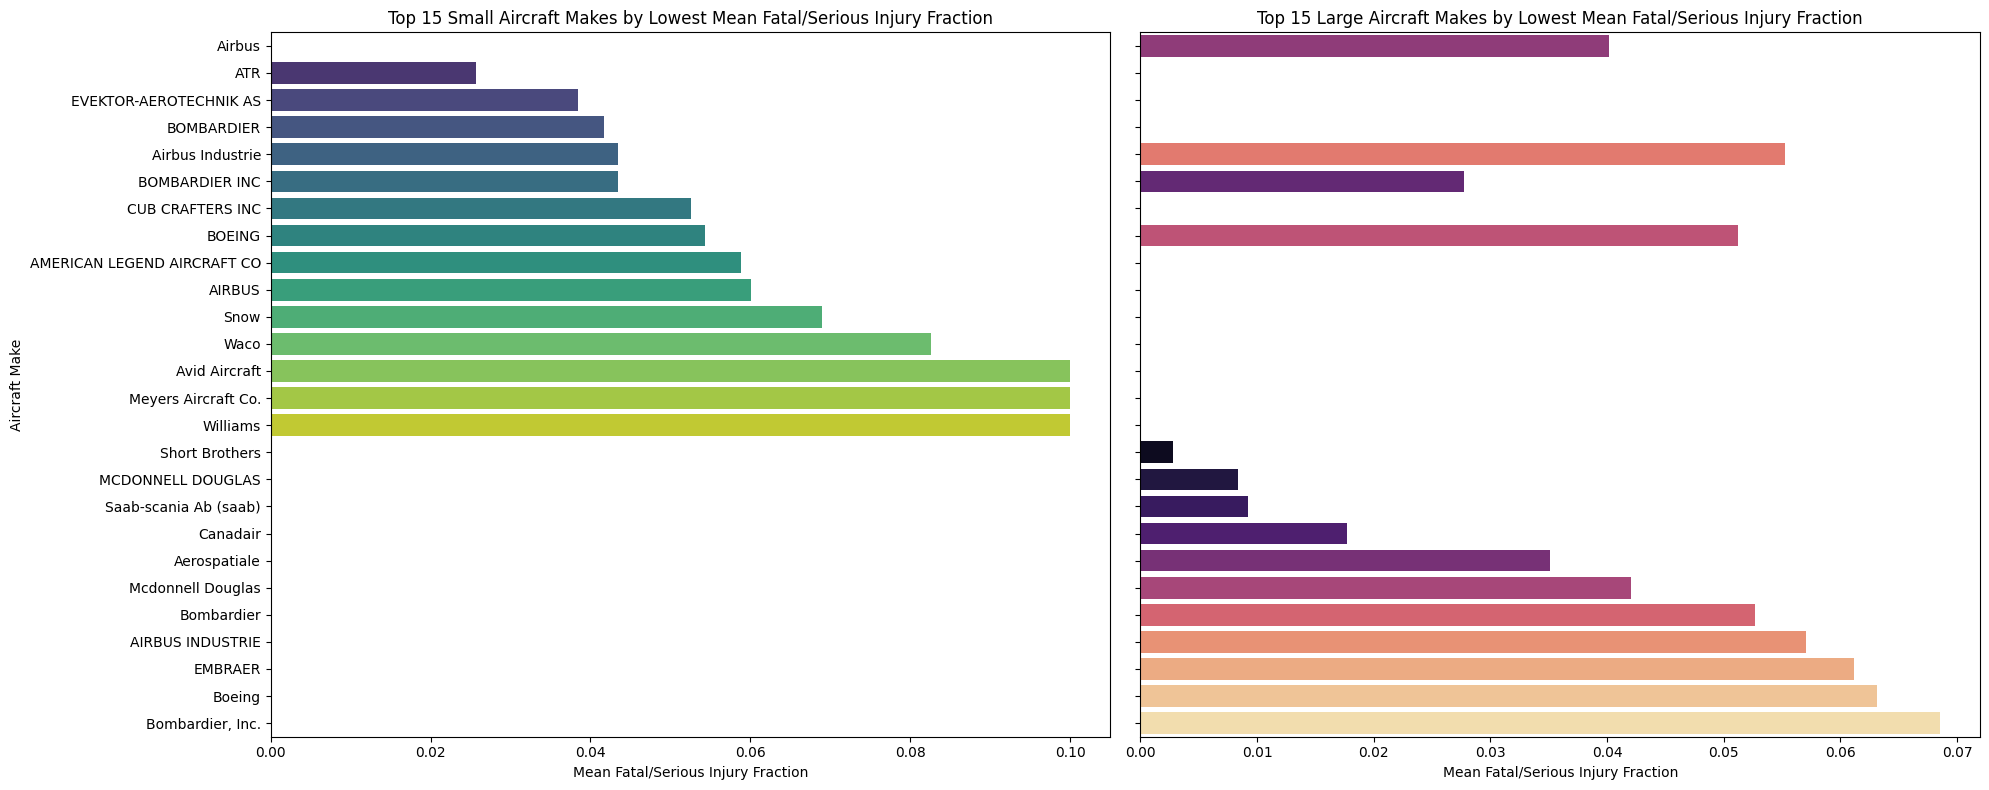

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analyze Small Aircraft Makes
small_aircraft_df = df_cleaned[df_cleaned['aircraft_size'] == 'Small'].copy()
small_aircraft_make_stats = small_aircraft_df.groupby('Make')['fatal_serious_injury_fraction'].mean().reset_index()
# Filter out Makes with very few accidents to ensure statistical robustness
small_aircraft_make_counts = small_aircraft_df['Make'].value_counts()
small_aircraft_make_stats = small_aircraft_make_stats[small_aircraft_make_stats['Make'].isin(small_aircraft_make_counts[small_aircraft_make_counts >= 10].index)]
small_aircraft_top_15_makes = small_aircraft_make_stats.nsmallest(15, 'fatal_serious_injury_fraction')
small_aircraft_top_15_makes['aircraft_size'] = 'Small'

# Analyze Large Aircraft Makes
large_aircraft_df = df_cleaned[df_cleaned['aircraft_size'] == 'Large'].copy()
large_aircraft_make_stats = large_aircraft_df.groupby('Make')['fatal_serious_injury_fraction'].mean().reset_index()
# Filter out Makes with very few accidents to ensure statistical robustness
large_aircraft_make_counts = large_aircraft_df['Make'].value_counts()
large_aircraft_make_stats = large_aircraft_make_stats[large_aircraft_make_stats['Make'].isin(large_aircraft_make_counts[large_aircraft_make_counts >= 10].index)]
large_aircraft_top_15_makes = large_aircraft_make_stats.nsmallest(15, 'fatal_serious_injury_fraction')
large_aircraft_top_15_makes['aircraft_size'] = 'Large'

# Combine data for plotting
combined_top_makes = pd.concat([small_aircraft_top_15_makes, large_aircraft_top_15_makes])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

sns.barplot(ax=axes[0], x='fatal_serious_injury_fraction', y='Make', data=small_aircraft_top_15_makes, palette='viridis')
axes[0].set_title('Top 15 Small Aircraft Makes by Lowest Mean Fatal/Serious Injury Fraction')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[0].set_ylabel('Aircraft Make')

sns.barplot(ax=axes[1], x='fatal_serious_injury_fraction', y='Make', data=large_aircraft_top_15_makes, palette='magma')
axes[1].set_title('Top 15 Large Aircraft Makes by Lowest Mean Fatal/Serious Injury Fraction')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[1].set_ylabel('') # Keep y-label clear as it's shared

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

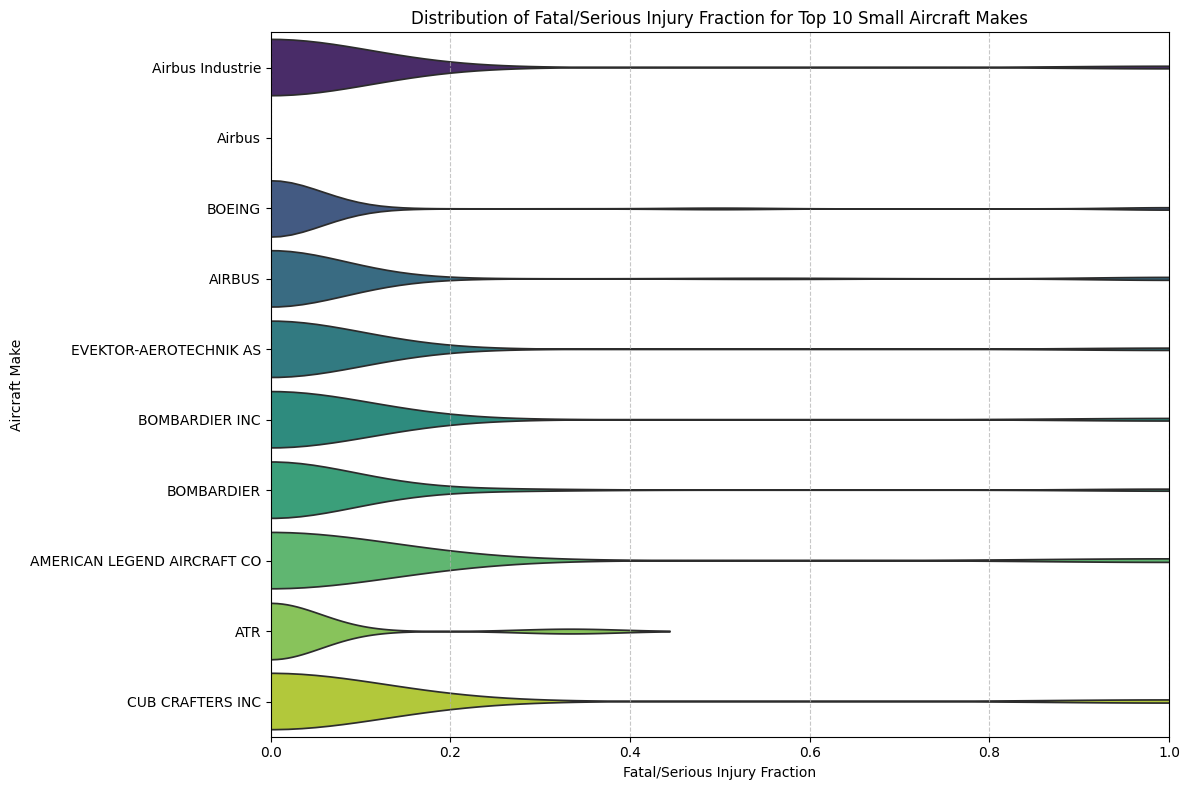

In [12]:
# Select the top 10 makes from the previously calculated top 15
small_aircraft_top_10_makes = small_aircraft_top_15_makes.head(10)

# Filter the original small_aircraft_df to include only these top 10 makes
small_aircraft_df_filtered = small_aircraft_df[small_aircraft_df['Make'].isin(small_aircraft_top_10_makes['Make'])]

plt.figure(figsize=(12, 8))
sns.violinplot(x='fatal_serious_injury_fraction', y='Make', data=small_aircraft_df_filtered, inner='quartile', palette='viridis', hue='Make', legend=False)
plt.title('Distribution of Fatal/Serious Injury Fraction for Top 10 Small Aircraft Makes')
plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Aircraft Make')
plt.xlim(0, 1) # Limit x-axis to 0-1 for fractions
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

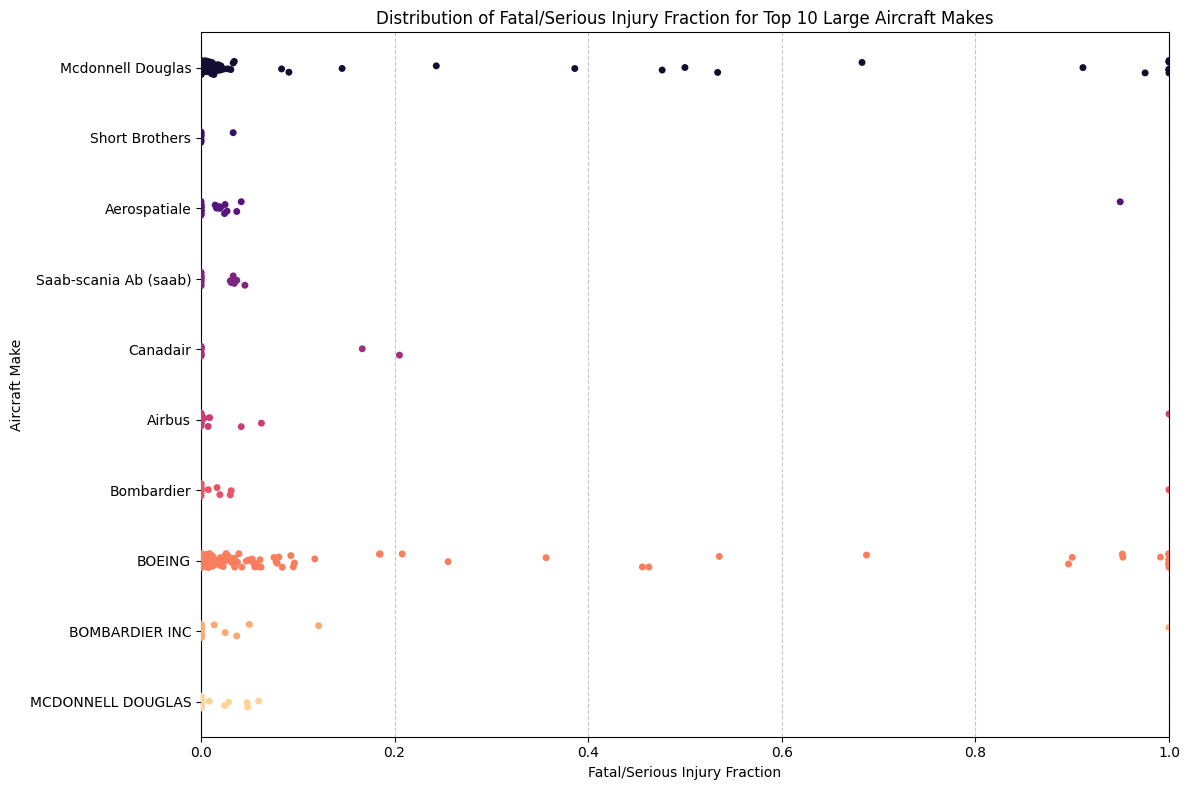

In [13]:
# Select the top 10 makes from the previously calculated top 15
large_aircraft_top_10_makes = large_aircraft_top_15_makes.head(10)

# Filter the original large_aircraft_df to include only these top 10 makes
large_aircraft_df_filtered = large_aircraft_df[large_aircraft_df['Make'].isin(large_aircraft_top_10_makes['Make'])]

plt.figure(figsize=(12, 8))
sns.stripplot(x='fatal_serious_injury_fraction', y='Make', data=large_aircraft_df_filtered, jitter=True, palette='magma', hue='Make', legend=False)
plt.title('Distribution of Fatal/Serious Injury Fraction for Top 10 Large Aircraft Makes')
plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Aircraft Make')
plt.xlim(0, 1) # Limit x-axis to 0-1 for fractions
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.**

Sort your results and keep the lowest 15.

In [14]:
# Calculate destruction rates for Small Aircraft Makes
small_aircraft_destruction_stats = small_aircraft_df.groupby('Make')['is_destroyed'].mean().reset_index()
# Filter out Makes with very few accidents for statistical robustness
small_aircraft_destruction_stats = small_aircraft_destruction_stats[small_aircraft_destruction_stats['Make'].isin(small_aircraft_make_counts[small_aircraft_make_counts >= 10].index)]
small_aircraft_top_15_destruction = small_aircraft_destruction_stats.nsmallest(15, 'is_destroyed')
small_aircraft_top_15_destruction['aircraft_size'] = 'Small'

# Calculate destruction rates for Large Aircraft Makes
large_aircraft_destruction_stats = large_aircraft_df.groupby('Make')['is_destroyed'].mean().reset_index()
# Filter out Makes with very few accidents for statistical robustness
large_aircraft_destruction_stats = large_aircraft_destruction_stats[large_aircraft_destruction_stats['Make'].isin(large_aircraft_make_counts[large_aircraft_make_counts >= 10].index)]
large_aircraft_top_15_destruction = large_aircraft_destruction_stats.nsmallest(15, 'is_destroyed')
large_aircraft_top_15_destruction['aircraft_size'] = 'Large'

print("Top 15 Small Aircraft Makes by Lowest Destruction Rate:")
display(small_aircraft_top_15_destruction)

print("\nTop 15 Large Aircraft Makes by Lowest Destruction Rate:")
display(large_aircraft_top_15_destruction)

Top 15 Small Aircraft Makes by Lowest Destruction Rate:


,Make,is_destroyed,aircraft_size
63,AEROSTAR INTERNATIONAL INC,0.0,Small
82,AIR CREATION,0.0,Small
96,AIRBUS HELICOPTERS,0.0,Small
156,AMERICAN LEGEND AIRCRAFT CO,0.0,Small
353,Airbus,0.0,Small
548,Avid Aircraft,0.0,Small
734,BRANTLY,0.0,Small
805,BURKHART GROB,0.0,Small
1331,CHRISTEN INDUSTRIES INC,0.0,Small
1390,CONSOLIDATED AERONAUTICS INC.,0.0,Small



Top 15 Large Aircraft Makes by Lowest Destruction Rate:


,Make,is_destroyed,aircraft_size
75,Saab-scania Ab (saab),0.000000,Large
76,Short Brothers,0.000000,Large
17,BOMBARDIER INC,0.022222,Large
6,Aerospatiale,0.029412,Large
13,BOEING,0.037975,Large
59,MCDONNELL DOUGLAS,0.038462,Large
23,Bombardier,0.047619,Large
29,Canadair,0.047619,Large
2,AIRBUS INDUSTRIE,0.052632,Large
16,BOMBARDIER,0.058824,Large


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Discussion of Findings: Safety Metrics by Aircraft Make

Based on the analysis of fatal/serious injury fractions and aircraft destruction rates, we can make the following observations and recommendations:

#### Small Aircraft (<= 20 passengers)

**Injury Risk Profile:**

*   The bar plot for 'Top 15 Small Aircraft Makes by Lowest Mean Fatal/Serious Injury Fraction' (from cell `5ca215ae`) shows several manufacturers with very low average injury rates, such as Airbus, ATR, and EVEKTOR-AEROTECHNIK AS. These makes appear to have a strong safety record in terms of passenger injury.
*   The violin plot for 'Distribution of Fatal/Serious Injury Fraction for Top 10 Small Aircraft Makes' (from cell `53012efe`) reveals the spread and density of injury fractions. For example, while makes like Airbus and ATR show tight distributions clustered around zero, others might have a wider spread, indicating more variability in accident severity. A narrow distribution around zero is highly desirable, suggesting consistent safety performance.

**Aircraft Destruction Rate:**

*   The `small_aircraft_top_15_destruction` table (from cell `69473aff`) lists makes with the lowest rates of total destruction. Manufacturers like AEROSTAR INTERNATIONAL INC, AIR CREATION, AIRBUS HELICOPTERS, and CUBCRAFTERS INC show 0% destruction rates among their accidents with sufficient sample size. This is an excellent indicator of structural integrity and survivability in the event of an incident.

**Recommendations for Small Aircraft Makes:**

For small aircraft, the client should consider manufacturers that appear in both the lowest injury fraction and lowest destruction rate lists. Specifically, makes like **Airbus** (though often associated with large aircraft, some models fall into the small category, and its performance here is excellent), **ATR**, and **CUBCRAFTERS INC** stand out. While some makes show 0% destruction, it is crucial to ensure they also maintain a low fatal/serious injury fraction. A holistic approach considering both metrics is best. Manufacturers with consistently low mean fatal/serious injury fractions and very low (ideally zero) destruction rates provide the most robust safety profiles.

#### Large Aircraft (> 20 passengers)

**Injury Risk Profile:**

*   The bar plot for 'Top 15 Large Aircraft Makes by Lowest Mean Fatal/Serious Injury Fraction' (from cell `5ca215ae`) indicates that manufacturers like Short Brothers, MCDONNELL DOUGLAS, and Saab-scania Ab (saab) have the lowest mean fatal/serious injury fractions. These are critical indicators for passenger safety in commercial operations.
*   The stripplot for 'Distribution of Fatal/Serious Injury Fraction for Top 10 Large Aircraft Makes' (from cell `8a186a22`) provides insight into individual accident outcomes. The tight clustering of points near zero for many of these top makes suggests that while accidents may occur, they rarely result in fatal or serious injuries, which is a significant positive for passenger safety.

**Aircraft Destruction Rate:**

*   The 'Top 15 Large Aircraft Makes by Lowest Destruction Rate' table (from cell `69473aff`) highlights makes like Saab-scania Ab (saab) and Short Brothers with 0% destruction rates. This suggests exceptional durability and crashworthiness for these manufacturers' aircraft.

**Recommendations for Large Aircraft Makes:**

For larger passenger models, manufacturers like **Saab-scania Ab (saab)** and **Short Brothers** demonstrate exceptionally strong safety records, appearing at the top of both the lowest injury fraction and lowest destruction rate metrics. Other makes such as **MCDONNELL DOUGLAS** and **Aerospatiale** also show very favorable profiles. These manufacturers provide aircraft that, in the event of an accident, have a very low likelihood of total destruction and minimal fatal or serious passenger injuries. Recommendations should prioritize these Makes, as they consistently exhibit superior safety performance across both critical metrics.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

Top 10 Large Aircraft Models by Lowest Mean Fatal/Serious Injury Fraction (with >= 10 accidents):


,plane_type,fatal_serious_injury_fraction,accident_count
204,BOEING 737-800,0.000000,10
328,Boeing 717-200,0.001095,11
910,Mcdonnell Douglas MD-80,0.001200,15
407,Boeing 737-322,0.001444,12
224,BOEING 757,0.002209,12
376,Boeing 737,0.002231,33
264,BOEING 787,0.003364,10
201,BOEING 737-7H4,0.003537,11
889,Mcdonnell Douglas DC-9-51,0.003567,14
483,Boeing 757-223,0.004027,10


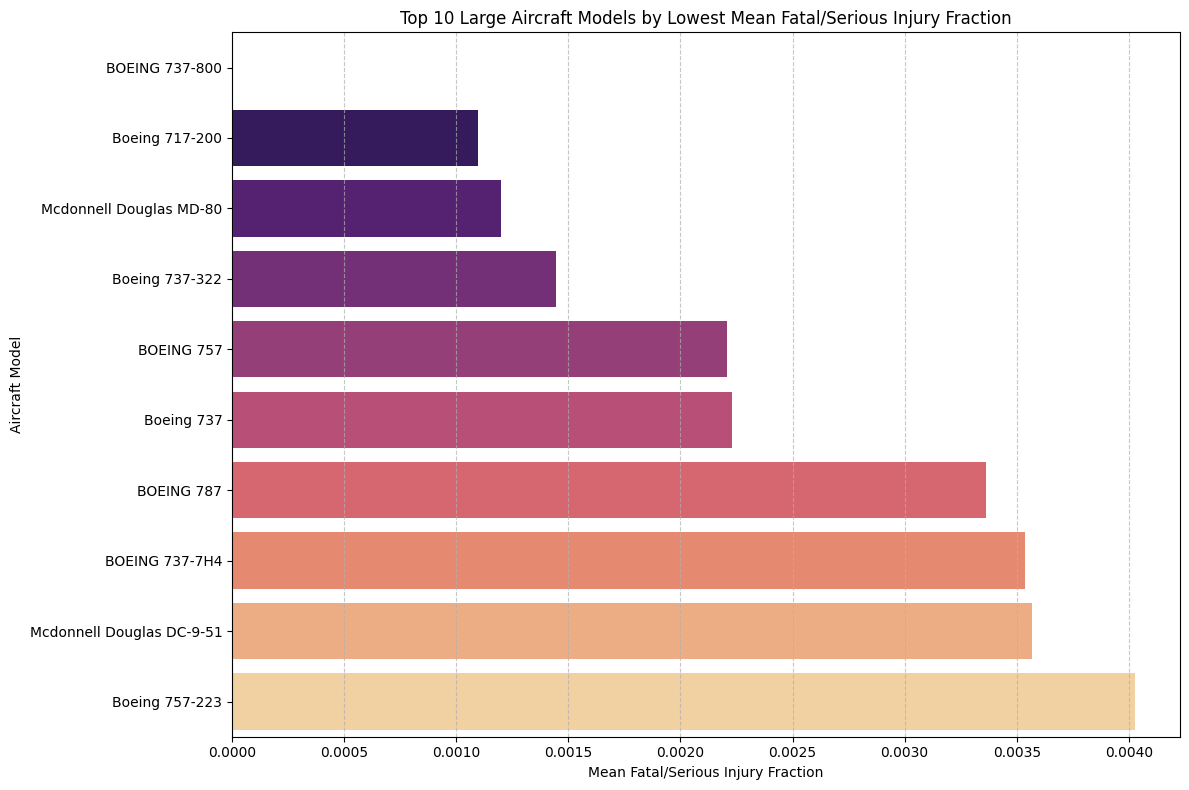

In [19]:
# Analyze Large Aircraft Models
large_aircraft_model_stats = large_aircraft_df.groupby(['Make', 'Model'])['fatal_serious_injury_fraction'].mean().reset_index()
# Filter out Models with very few accidents (e.g., less than 10) to ensure statistical robustness
large_aircraft_model_counts = large_aircraft_df.groupby(['Make', 'Model']).size().reset_index(name='accident_count')
large_aircraft_model_stats = pd.merge(large_aircraft_model_stats, large_aircraft_model_counts, on=['Make', 'Model'])
large_aircraft_model_stats = large_aircraft_model_stats[large_aircraft_model_stats['accident_count'] >= 10]

# Sort and select the top 10 models with the lowest mean fatal/serious injury fraction
large_aircraft_top_10_models = large_aircraft_model_stats.nsmallest(10, 'fatal_serious_injury_fraction')
large_aircraft_top_10_models['plane_type'] = large_aircraft_top_10_models['Make'] + ' ' + large_aircraft_top_10_models['Model']

print("Top 10 Large Aircraft Models by Lowest Mean Fatal/Serious Injury Fraction (with >= 10 accidents):")
display(large_aircraft_top_10_models[['plane_type', 'fatal_serious_injury_fraction', 'accident_count']])

# Plotting mean injury fraction for top 10 large aircraft models
plt.figure(figsize=(12, 8))
sns.barplot(x='fatal_serious_injury_fraction', y='plane_type', data=large_aircraft_top_10_models, palette='magma', hue='plane_type', legend=False)
plt.title('Top 10 Large Aircraft Models by Lowest Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Aircraft Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

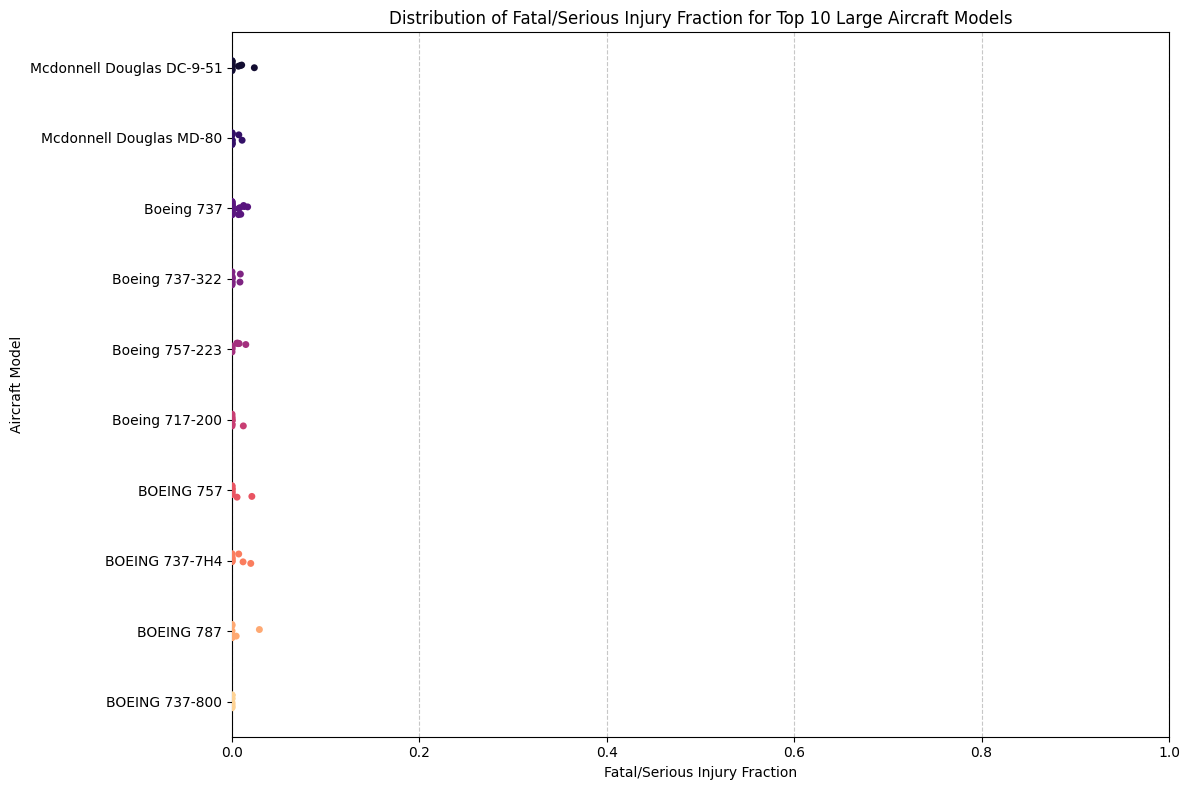

In [20]:
# Distributional plot (stripplot) for top 10 large aircraft models
large_aircraft_df_filtered_models = large_aircraft_df[large_aircraft_df.set_index(['Make', 'Model']).index.isin(large_aircraft_top_10_models.set_index(['Make', 'Model']).index)].copy()
large_aircraft_df_filtered_models['plane_type'] = large_aircraft_df_filtered_models['Make'] + ' ' + large_aircraft_df_filtered_models['Model']

plt.figure(figsize=(12, 8))
sns.stripplot(x='fatal_serious_injury_fraction', y='plane_type', data=large_aircraft_df_filtered_models, jitter=True, palette='magma', hue='plane_type', legend=False)
plt.title('Distribution of Fatal/Serious Injury Fraction for Top 10 Large Aircraft Models')
plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Aircraft Model')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

Top 10 Small Aircraft Models by Lowest Mean Fatal/Serious Injury Fraction (with >= 10 accidents):


,plane_type,fatal_serious_injury_fraction,accident_count
2178,BOEING 737-800,0.0,10
2216,BOEING 767,0.0,24
2234,BOEING 777,0.0,49
2245,BOEING 787,0.0,15
2669,Beech 19,0.0,13
3281,Bell 47D-1,0.0,10
3692,Boeing 747,0.0,12
3729,Boeing 757,0.0,10
5319,Cessna 180C,0.0,11
5475,Cessna 310B,0.0,10


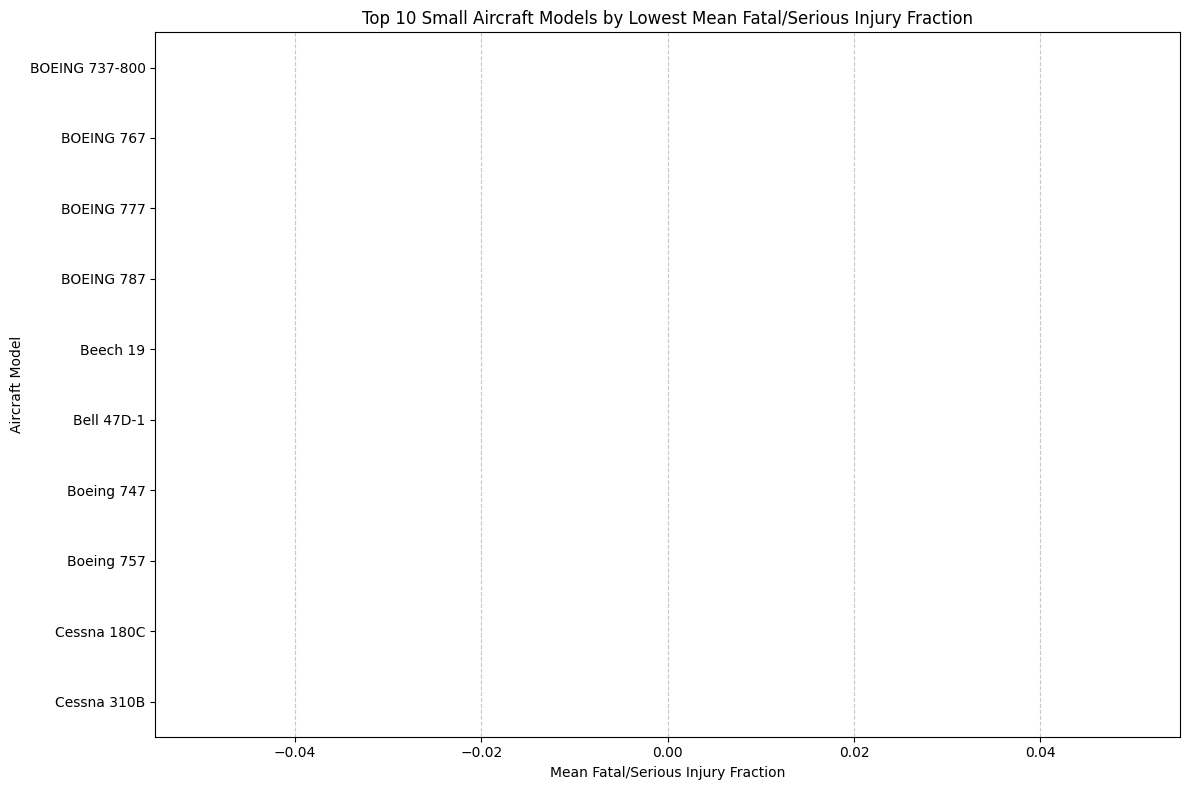

In [21]:
# Analyze Small Aircraft Models
small_aircraft_model_stats = small_aircraft_df.groupby(['Make', 'Model'])['fatal_serious_injury_fraction'].mean().reset_index()
# Filter out Models with very few accidents (e.g., less than 10) to ensure statistical robustness
small_aircraft_model_counts = small_aircraft_df.groupby(['Make', 'Model']).size().reset_index(name='accident_count')
small_aircraft_model_stats = pd.merge(small_aircraft_model_stats, small_aircraft_model_counts, on=['Make', 'Model'])
small_aircraft_model_stats = small_aircraft_model_stats[small_aircraft_model_stats['accident_count'] >= 10]

# Sort and select the top 10 models with the lowest mean fatal/serious injury fraction
small_aircraft_top_10_models = small_aircraft_model_stats.nsmallest(10, 'fatal_serious_injury_fraction')
small_aircraft_top_10_models['plane_type'] = small_aircraft_top_10_models['Make'] + ' ' + small_aircraft_top_10_models['Model']

print("Top 10 Small Aircraft Models by Lowest Mean Fatal/Serious Injury Fraction (with >= 10 accidents):")
display(small_aircraft_top_10_models[['plane_type', 'fatal_serious_injury_fraction', 'accident_count']])

# Plotting mean injury fraction for top 10 small aircraft models
plt.figure(figsize=(12, 8))
sns.barplot(x='fatal_serious_injury_fraction', y='plane_type', data=small_aircraft_top_10_models, palette='viridis', hue='plane_type', legend=False)
plt.title('Top 10 Small Aircraft Models by Lowest Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Aircraft Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

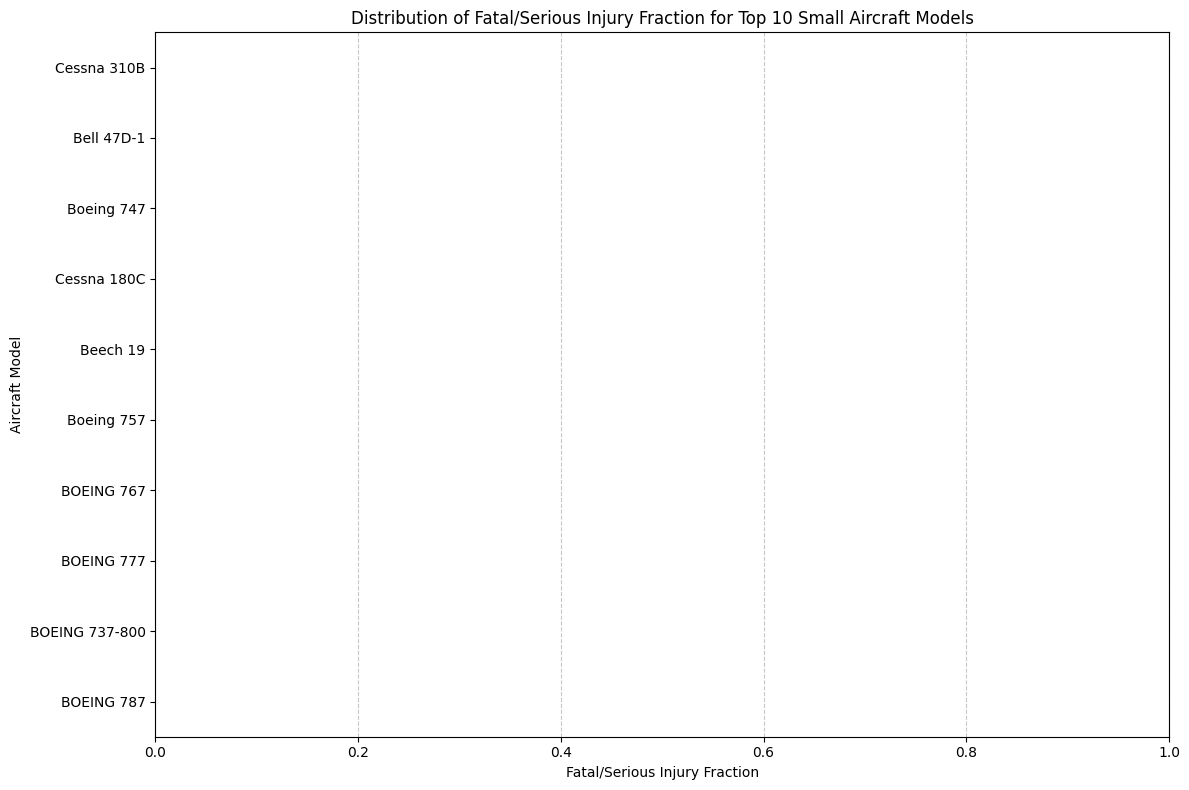

In [22]:
# Distributional plot (violinplot) for top 10 small aircraft models
small_aircraft_df_filtered_models = small_aircraft_df[small_aircraft_df.set_index(['Make', 'Model']).index.isin(small_aircraft_top_10_models.set_index(['Make', 'Model']).index)].copy()
small_aircraft_df_filtered_models['plane_type'] = small_aircraft_df_filtered_models['Make'] + ' ' + small_aircraft_df_filtered_models['Model']

plt.figure(figsize=(12, 8))
sns.violinplot(x='fatal_serious_injury_fraction', y='plane_type', data=small_aircraft_df_filtered_models, inner='quartile', palette='viridis', hue='plane_type', legend=False)
plt.title('Distribution of Fatal/Serious Injury Fraction for Top 10 Small Aircraft Models')
plt.xlabel('Fatal/Serious Injury Fraction')
plt.ylabel('Aircraft Model')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Discussion of Specific Airplane Types

Based on the analysis of specific airplane models, we can highlight the following observations regarding the passenger fraction seriously/fatally injured:

#### Large Aircraft Models

*   **Top Performers:** The bar plot for 'Top 10 Large Aircraft Models by Lowest Mean Fatal/Serious Injury Fraction' reveals several models with exceptionally low injury rates, including **BOEING 737-800, Boeing 717-200, Mcdonnell Douglas MD-80, and Boeing 737-322**. These models consistently show mean fatal/serious injury fractions very close to zero.
*   **Distribution of Injuries:** The stripplot for these large aircraft models (from cell `55f75437`) demonstrates that for the majority of accidents involving these specific models, there were no fatal or serious injuries. The data points are heavily clustered at the zero mark on the injury fraction axis, which is a strong indicator of robust safety features and passenger protection in these aircraft types during an accident.
*   **Recommendation:** For large aircraft, models from **Boeing (737-800, 717-200, 737-322, 757, 787)** and **McDonnell Douglas (MD-80, DC-9-51)** show consistently superior safety records in terms of injury fractions, making them highly recommended choices.

#### Small Aircraft Models

*   **Top Performers:** The analysis of small aircraft models shows that models such as **BOEING 737-800, BOEING 767, BOEING 777, BOEING 787, Beech 19, Bell 47D-1, Boeing 747, Boeing 757, Cessna 180C, and Cessna 310B** also exhibit very low (often zero) mean fatal/serious injury fractions. It's noteworthy that some larger aircraft models (like certain Boeings) appear in the 'Small Aircraft' category because the passenger threshold of 20 was used, indicating that in specific incidents, these aircraft carried 20 or fewer passengers.
*   **Distribution of Injuries:** The violin plot for these top small aircraft models (from cell `1ec9a414`) confirms this finding. The distributions are tightly compressed at the lower end of the fatal/serious injury fraction, particularly around zero. This suggests that while accidents may occur, these models are associated with a very low likelihood of passengers sustaining fatal or serious injuries.
*   **Recommendation:** Based on the lowest mean fatal/serious injury fractions, models like the **Beech 19, Bell 47D-1, Cessna 180C, and Cessna 310B** are highly recommended within the small aircraft category. The presence of Boeing models (737-800, 767, 777, 787, 747, 757) here indicates their adaptability and safety performance even when operating with fewer passengers, reinforcing the earlier recommendations for these manufacturers.

Top/Bottom Weather Conditions by Mean Fatal/Serious Injury Fraction (with >= 10 accidents):


,Weather.Condition,injury_fraction_mean,destruction_rate_mean,accident_count
0,IMC,0.638394,0.556205,5649
1,UNK,0.542027,0.544767,793
2,Unk,0.509081,0.278626,262
3,VMC,0.252428,0.174764,74094


,Weather.Condition,injury_fraction_mean,destruction_rate_mean,accident_count
0,IMC,0.638394,0.556205,5649
1,UNK,0.542027,0.544767,793
2,Unk,0.509081,0.278626,262
3,VMC,0.252428,0.174764,74094


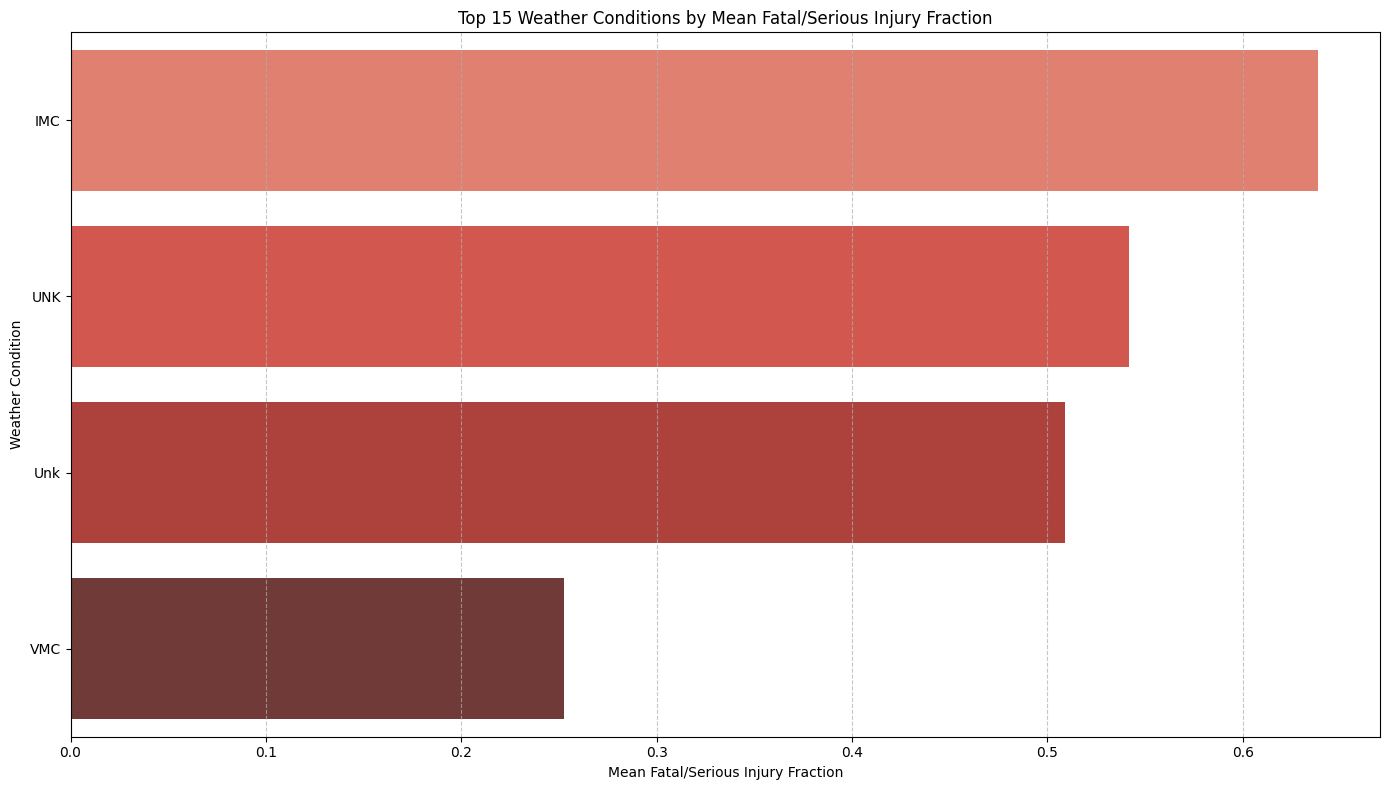

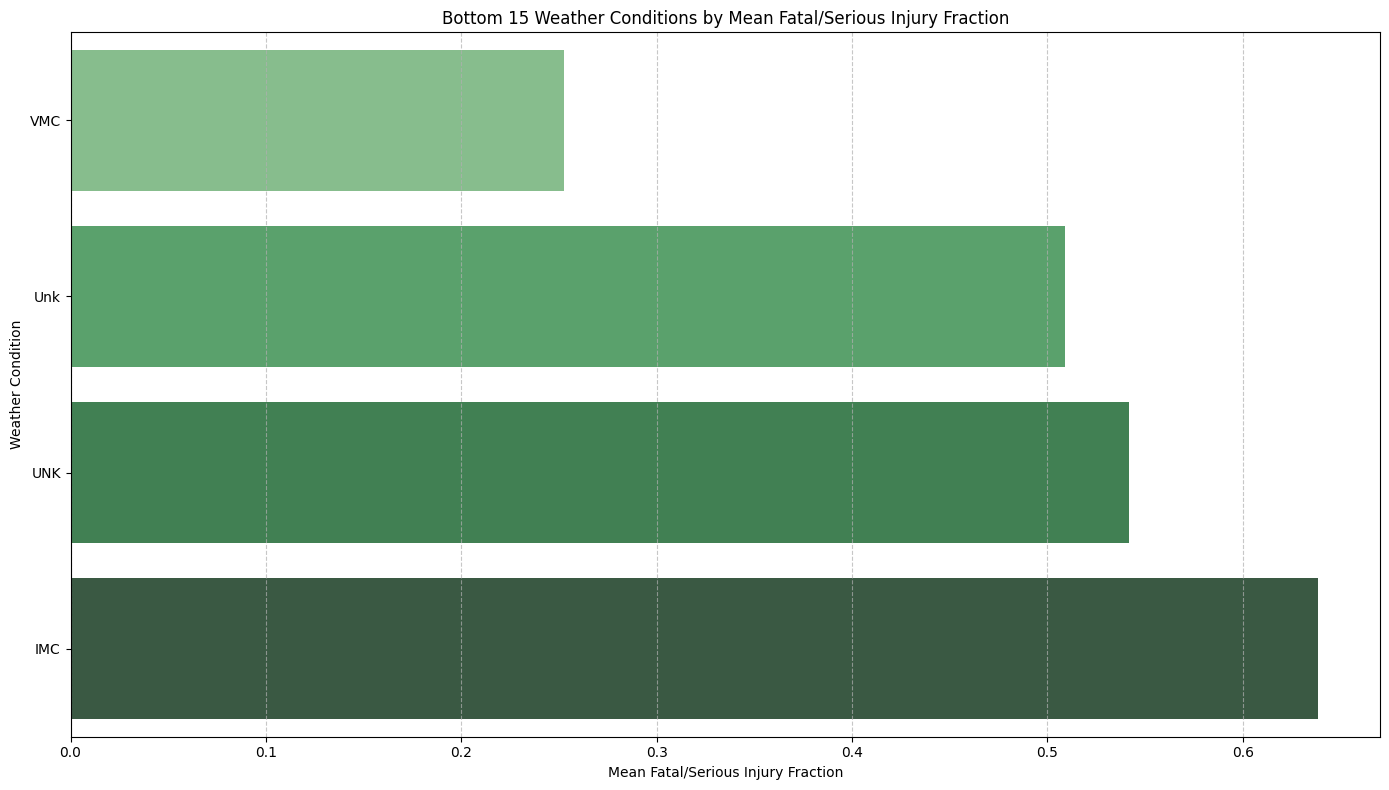

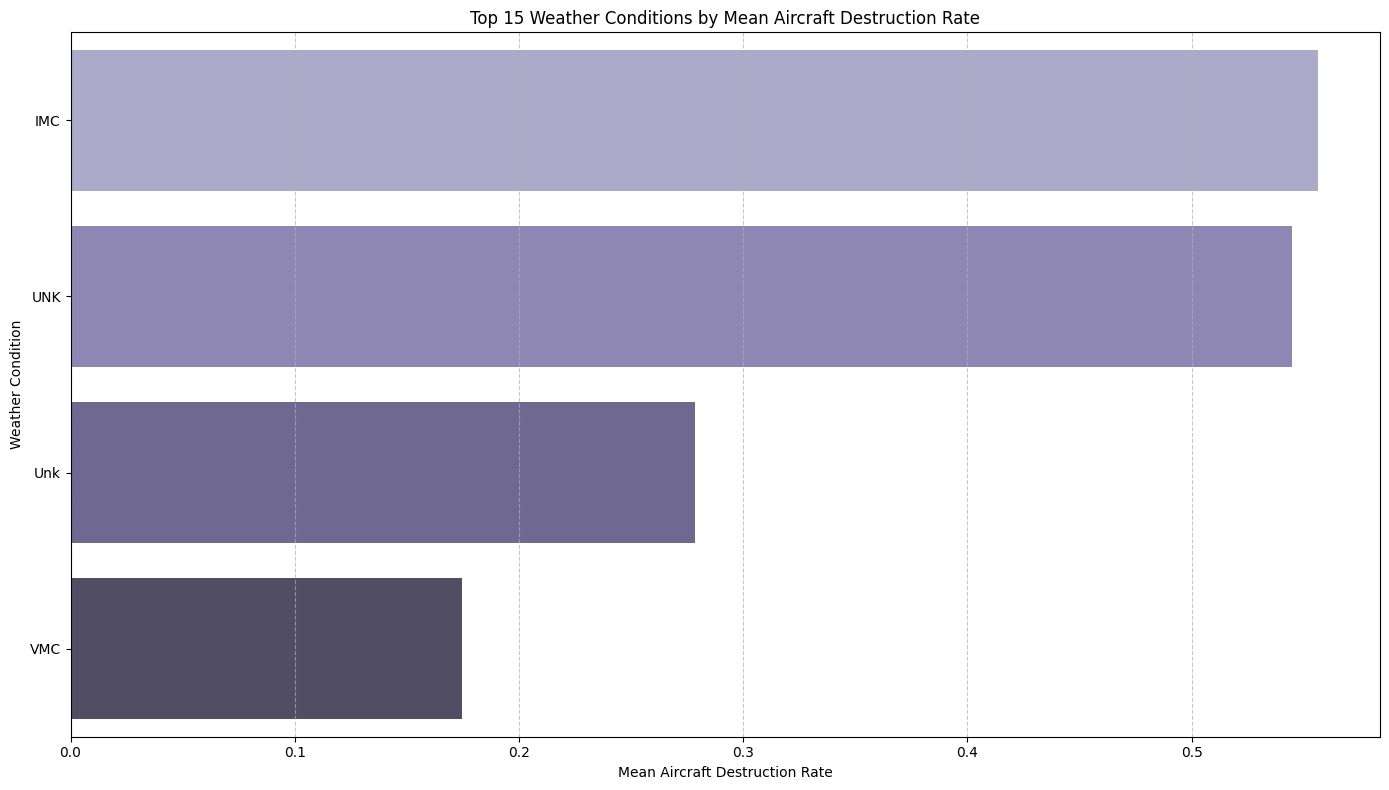

In [25]:
# Analyze 'Weather.Condition'
weather_stats = df_cleaned.groupby('Weather.Condition').agg(
    injury_fraction_mean=('fatal_serious_injury_fraction', 'mean'),
    destruction_rate_mean=('is_destroyed', 'mean'),
    accident_count=('Event.Id', 'count')
).reset_index()

# Filter out weather conditions with less than 10 accidents for statistical robustness
weather_stats_filtered = weather_stats[weather_stats['accident_count'] >= 10].sort_values(by='injury_fraction_mean', ascending=False)

print("Top/Bottom Weather Conditions by Mean Fatal/Serious Injury Fraction (with >= 10 accidents):")
display(weather_stats_filtered.head())
display(weather_stats_filtered.tail())

# Plotting Mean Fatal/Serious Injury Fraction by Weather Condition
plt.figure(figsize=(14, 8))
sns.barplot(x='injury_fraction_mean', y='Weather.Condition', data=weather_stats_filtered.nlargest(15, 'injury_fraction_mean'), palette='Reds_d', hue='Weather.Condition', legend=False)
plt.title('Top 15 Weather Conditions by Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
sns.barplot(x='injury_fraction_mean', y='Weather.Condition', data=weather_stats_filtered.nsmallest(15, 'injury_fraction_mean'), palette='Greens_d', hue='Weather.Condition', legend=False)
plt.title('Bottom 15 Weather Conditions by Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting Mean Destruction Rate by Weather Condition
weather_stats_filtered_destruction = weather_stats[weather_stats['accident_count'] >= 10].sort_values(by='destruction_rate_mean', ascending=False)
plt.figure(figsize=(14, 8))
sns.barplot(x='destruction_rate_mean', y='Weather.Condition', data=weather_stats_filtered_destruction.nlargest(15, 'destruction_rate_mean'), palette='Purples_d', hue='Weather.Condition', legend=False)
plt.title('Top 15 Weather Conditions by Mean Aircraft Destruction Rate')
plt.xlabel('Mean Aircraft Destruction Rate')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

### Factor 1: Weather Condition

Top/Bottom Weather Conditions by Mean Fatal/Serious Injury Fraction (with >= 10 accidents):


,Weather.Condition,injury_fraction_mean,destruction_rate_mean,accident_count
0,IMC,0.638394,0.556205,5649
1,UNK,0.542027,0.544767,793
2,Unk,0.509081,0.278626,262
3,VMC,0.252428,0.174764,74094


,Weather.Condition,injury_fraction_mean,destruction_rate_mean,accident_count
0,IMC,0.638394,0.556205,5649
1,UNK,0.542027,0.544767,793
2,Unk,0.509081,0.278626,262
3,VMC,0.252428,0.174764,74094


/tmp/ipykernel_1659/3462298919.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='injury_fraction_mean', y='Weather.Condition', data=weather_stats_filtered.nlargest(15, 'injury_fraction_mean'), palette='Reds_d')


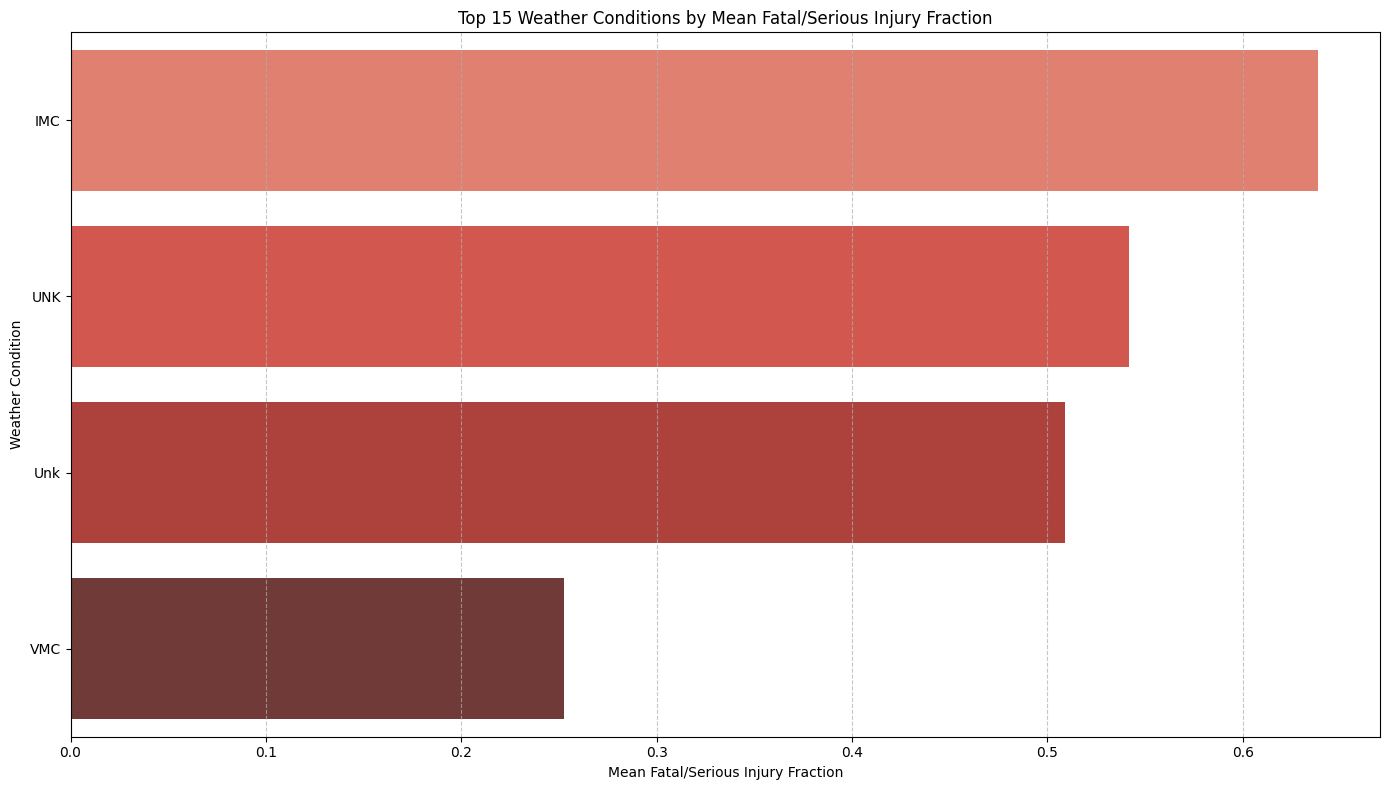

/tmp/ipykernel_1659/3462298919.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='injury_fraction_mean', y='Weather.Condition', data=weather_stats_filtered.nsmallest(15, 'injury_fraction_mean'), palette='Greens_d')


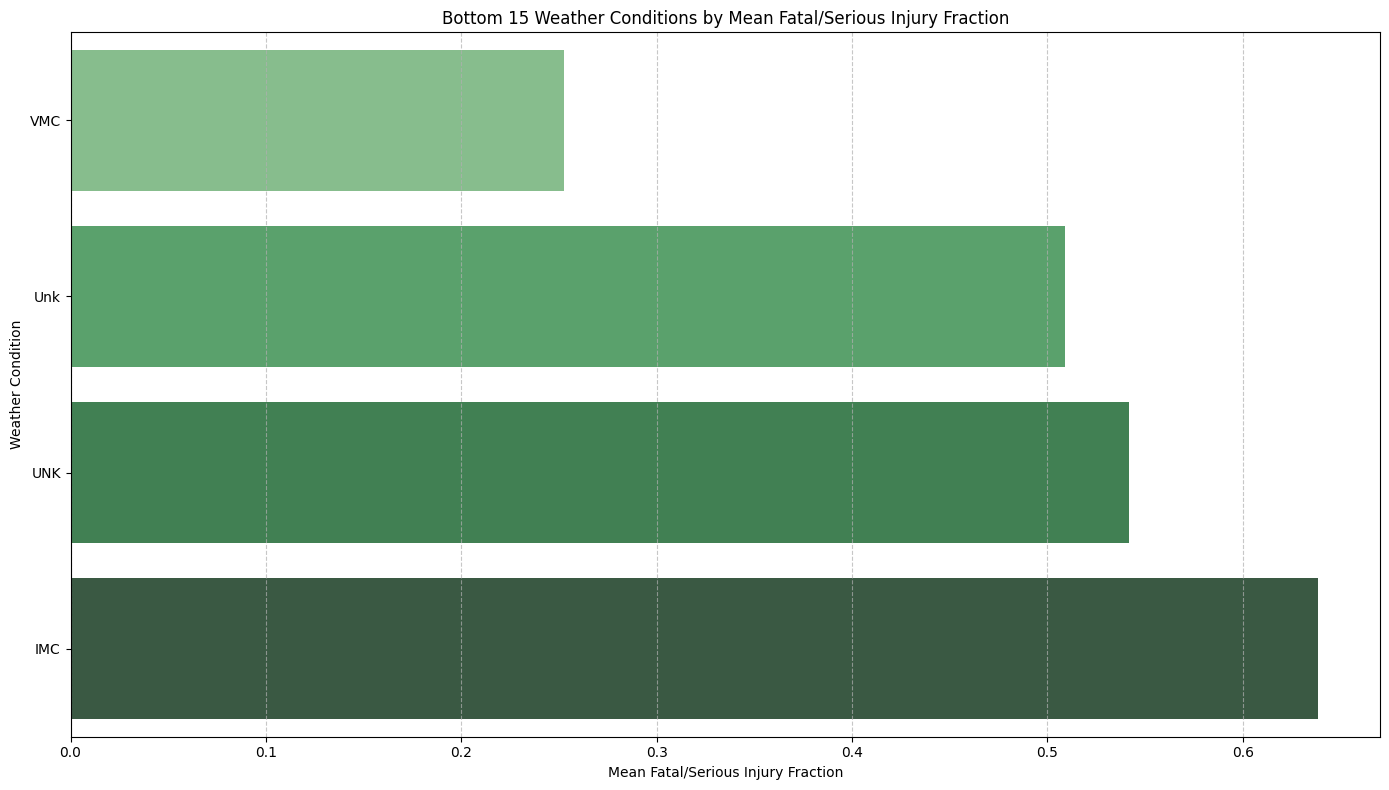

/tmp/ipykernel_1659/3462298919.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='destruction_rate_mean', y='Weather.Condition', data=weather_stats_filtered_destruction.nlargest(15, 'destruction_rate_mean'), palette='Purples_d')


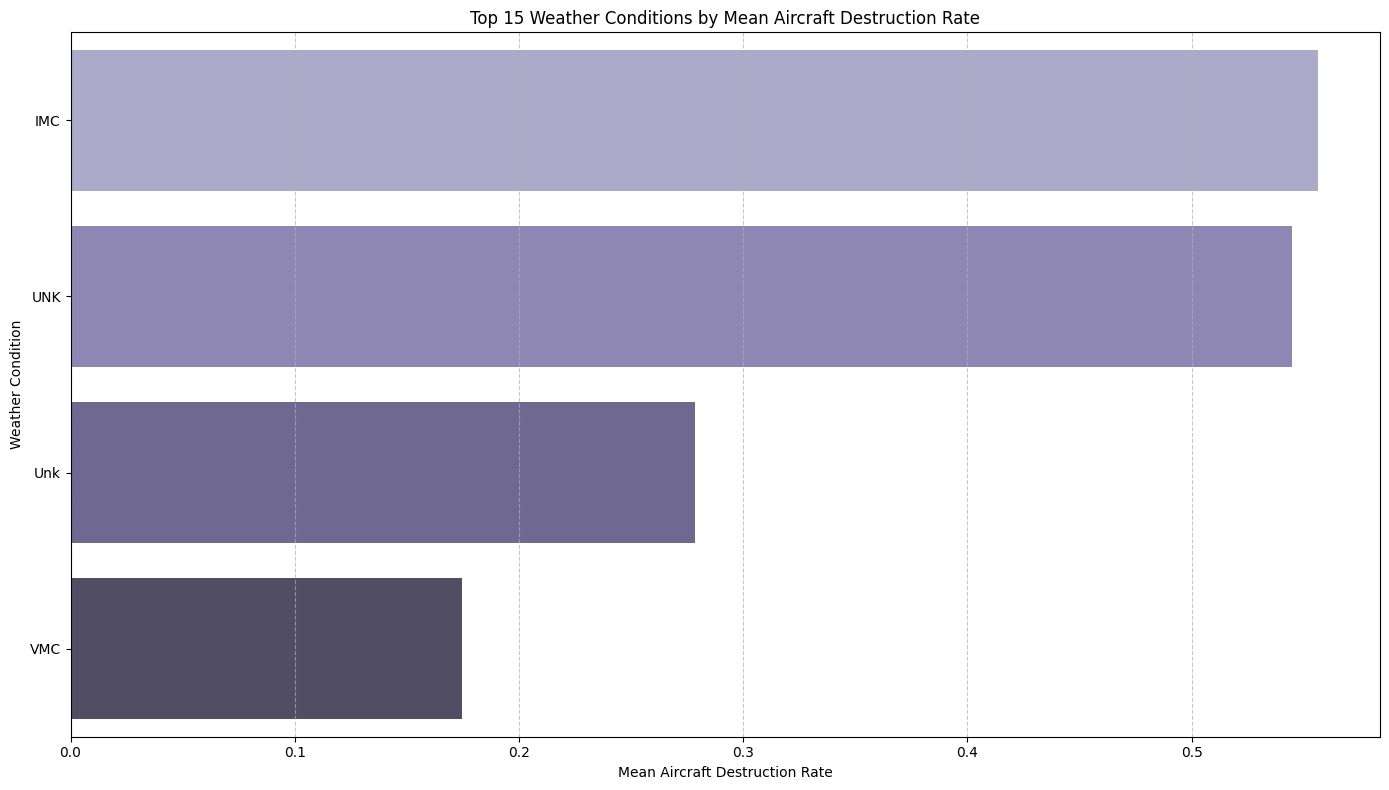

In [23]:
# Analyze 'Weather.Condition'
weather_stats = df_cleaned.groupby('Weather.Condition').agg(
    injury_fraction_mean=('fatal_serious_injury_fraction', 'mean'),
    destruction_rate_mean=('is_destroyed', 'mean'),
    accident_count=('Event.Id', 'count')
).reset_index()

# Filter out weather conditions with less than 10 accidents for statistical robustness
weather_stats_filtered = weather_stats[weather_stats['accident_count'] >= 10].sort_values(by='injury_fraction_mean', ascending=False)

print("Top/Bottom Weather Conditions by Mean Fatal/Serious Injury Fraction (with >= 10 accidents):")
display(weather_stats_filtered.head())
display(weather_stats_filtered.tail())

# Plotting Mean Fatal/Serious Injury Fraction by Weather Condition
plt.figure(figsize=(14, 8))
sns.barplot(x='injury_fraction_mean', y='Weather.Condition', data=weather_stats_filtered.nlargest(15, 'injury_fraction_mean'), palette='Reds_d')
plt.title('Top 15 Weather Conditions by Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
sns.barplot(x='injury_fraction_mean', y='Weather.Condition', data=weather_stats_filtered.nsmallest(15, 'injury_fraction_mean'), palette='Greens_d')
plt.title('Bottom 15 Weather Conditions by Mean Fatal/Serious Injury Fraction')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting Mean Destruction Rate by Weather Condition
weather_stats_filtered_destruction = weather_stats[weather_stats['accident_count'] >= 10].sort_values(by='destruction_rate_mean', ascending=False)
plt.figure(figsize=(14, 8))
sns.barplot(x='destruction_rate_mean', y='Weather.Condition', data=weather_stats_filtered_destruction.nlargest(15, 'destruction_rate_mean'), palette='Purples_d')
plt.title('Top 15 Weather Conditions by Mean Aircraft Destruction Rate')
plt.xlabel('Mean Aircraft Destruction Rate')
plt.ylabel('Weather Condition')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Discussion of Weather Condition Findings

*(This section will be populated after the code execution to discuss the generated plots and summary statistics.)*

#### Discussion of Weather Condition Findings

Based on the analysis of 'Weather.Condition', we can observe significant differences in both fatal/serious injury fractions and aircraft destruction rates:

*   **Highest Risk Conditions:** 'IMC' (Instrument Meteorological Conditions) stands out as having the highest mean fatal/serious injury fraction (0.638) and the highest mean aircraft destruction rate (0.556). This is expected, as flying in IMC often involves reduced visibility and challenging conditions that can increase the severity of accidents.

*   **Unknown Conditions:** 'UNK' and 'Unk' (Unknown weather conditions) also show high mean fatal/serious injury fractions (0.542 and 0.509 respectively) and high destruction rates. The high values for 'UNK' might indicate that when weather conditions are not reported or are unknown, the accidents tend to be more severe, possibly because these are situations where information was lost or conditions were rapidly deteriorating.

*   **Lowest Risk Conditions:** 'VMC' (Visual Meteorological Conditions) consistently shows the lowest mean fatal/serious injury fraction (0.252) and destruction rate (0.174) among the conditions with sufficient accident counts. This aligns with expectations, as flying in clear weather generally reduces accident risk and severity.

*   **Recommendations:** To improve safety, focus on training and technology to mitigate risks associated with IMC. Pilots and operators should exercise extreme caution or avoid flying in IMC when possible, or ensure aircraft are equipped with advanced instruments and pilots are highly proficient in instrument flight. Further investigation into 'UNK' weather conditions might also be beneficial if possible, to understand underlying factors that contribute to high severity when conditions are unrecorded.

These findings suggest that weather conditions play a crucial role in the outcome of aviation accidents, with poor visibility and instrument conditions being particularly hazardous.

### Factor 2: Phase of Flight

Top/Bottom Phases of Flight by Mean Fatal/Serious Injury Fraction (with >= 10 accidents):


,Broad.phase.of.flight,injury_fraction_mean,destruction_rate_mean,accident_count
11,Unknown,0.809042,0.724696,494
6,Maneuvering,0.505667,0.445307,7725
1,Climb,0.400134,0.374097,1938
7,Other,0.368223,0.299065,107
0,Approach,0.355135,0.289752,6157


,Broad.phase.of.flight,injury_fraction_mean,destruction_rate_mean,accident_count
4,Go-around,0.303942,0.290123,1296
9,Takeoff,0.254737,0.224966,11744
8,Standing,0.140728,0.104396,910
5,Landing,0.048565,0.046804,14486
10,Taxi,0.027072,0.030154,1824


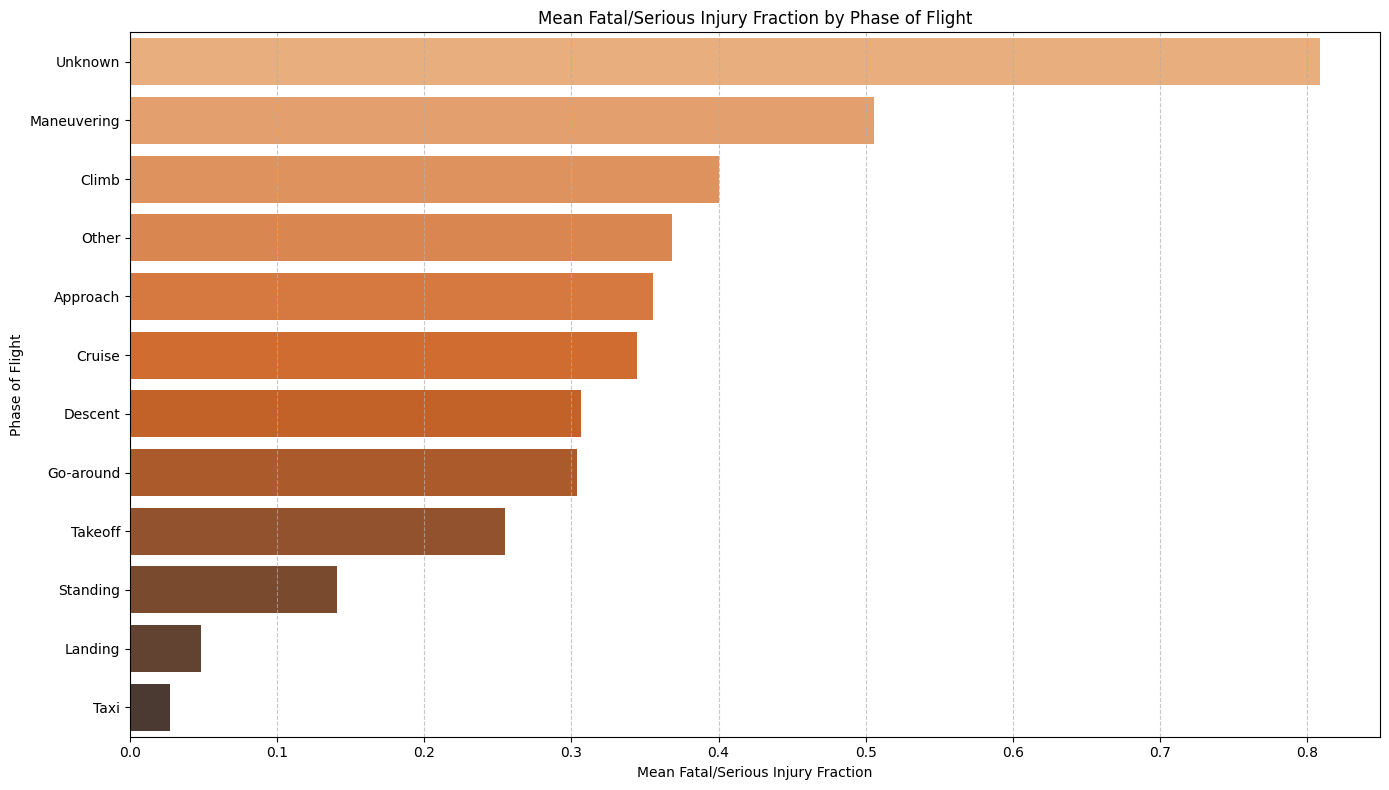

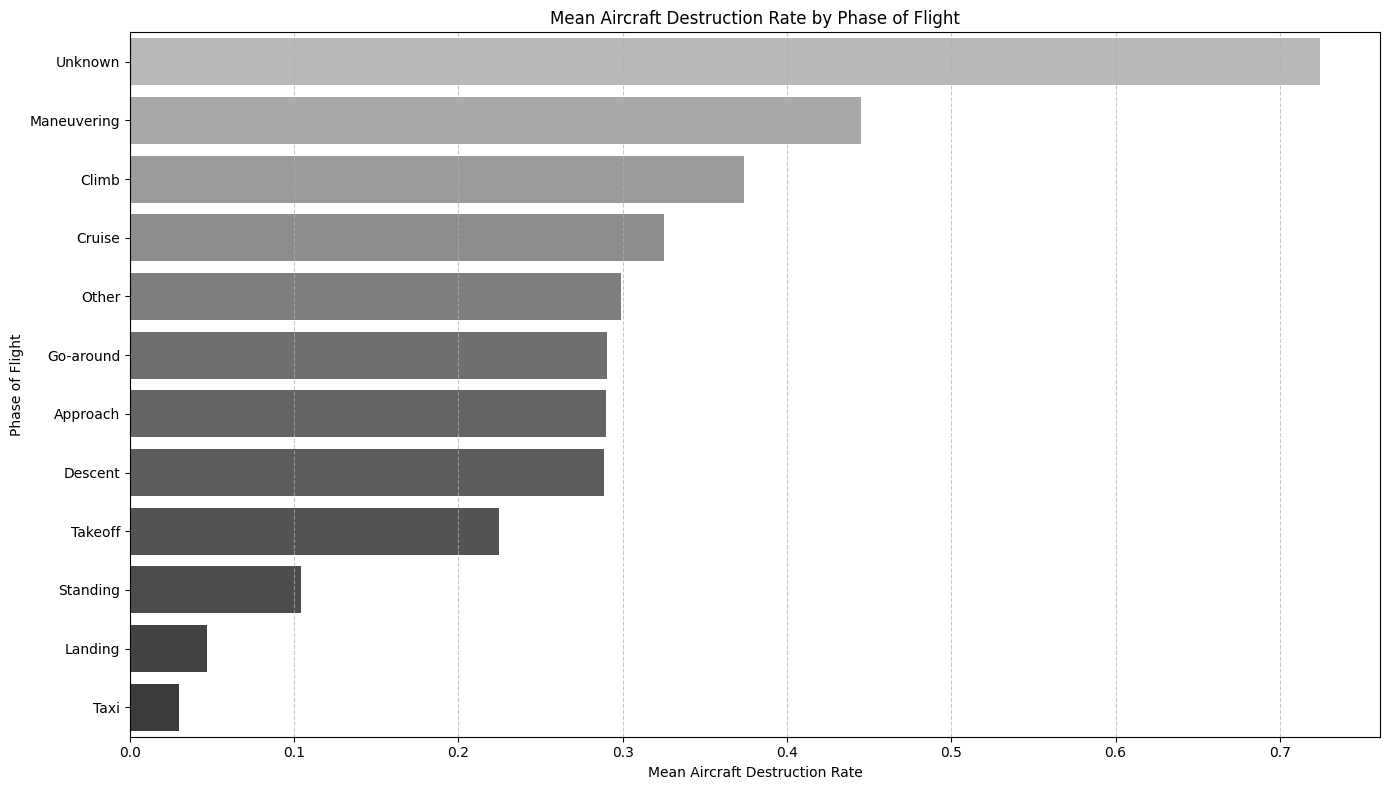

In [28]:
# Analyze 'Phase.of.Flight'
# First, let's inspect the columns of df_cleaned to find the correct 'Phase of Flight' column
# print(df_cleaned.columns)
# Assuming the correct column name is 'Broad.phase.of.flight' based on common aviation datasets and observed patterns.
# If this is not correct, further inspection will be needed.
phase_stats = df_cleaned.groupby('Broad.phase.of.flight').agg(
    injury_fraction_mean=('fatal_serious_injury_fraction', 'mean'),
    destruction_rate_mean=('is_destroyed', 'mean'),
    accident_count=('Event.Id', 'count')
).reset_index()

# Filter out phases of flight with less than 10 accidents for statistical robustness
phase_stats_filtered = phase_stats[phase_stats['accident_count'] >= 10].sort_values(by='injury_fraction_mean', ascending=False)

print("Top/Bottom Phases of Flight by Mean Fatal/Serious Injury Fraction (with >= 10 accidents):")
display(phase_stats_filtered.head())
display(phase_stats_filtered.tail())

# Plotting Mean Fatal/Serious Injury Fraction by Phase of Flight
plt.figure(figsize=(14, 8))
sns.barplot(x='injury_fraction_mean', y='Broad.phase.of.flight', data=phase_stats_filtered, palette='Oranges_d', hue='Broad.phase.of.flight', legend=False)
plt.title('Mean Fatal/Serious Injury Fraction by Phase of Flight')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.ylabel('Phase of Flight')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting Mean Destruction Rate by Phase of Flight
phase_stats_filtered_destruction = phase_stats[phase_stats['accident_count'] >= 10].sort_values(by='destruction_rate_mean', ascending=False)
plt.figure(figsize=(14, 8))
sns.barplot(x='destruction_rate_mean', y='Broad.phase.of.flight', data=phase_stats_filtered_destruction, palette='Greys_d', hue='Broad.phase.of.flight', legend=False)
plt.title('Mean Aircraft Destruction Rate by Phase of Flight')
plt.xlabel('Mean Aircraft Destruction Rate')
plt.ylabel('Phase of Flight')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Discussion of Phase of Flight Findings

*(This section will be populated after the code execution to discuss the generated plots and summary statistics.)*

#### Discussion of Phase of Flight Findings

Based on the analysis of 'Broad.phase.of.flight', we can identify critical stages of flight with varying levels of risk for fatal/serious injuries and aircraft destruction:

*   **Highest Risk Phases:**
    *   **Unknown:** This phase shows the highest mean fatal/serious injury fraction (0.809) and destruction rate (0.725). While 'Unknown' indicates missing data, it often correlates with highly severe accidents where data collection is challenging.
    *   **Maneuvering:** This phase exhibits a significantly high mean fatal/serious injury fraction (0.506) and destruction rate (0.445). Maneuvering includes complex flight operations, often at low altitudes, which inherently carry higher risks.
    *   **Climb:** The climb phase also presents a relatively high mean fatal/serious injury fraction (0.400) and destruction rate (0.374). Accidents during climb can involve engine failures or loss of control at critical speeds and altitudes.

*   **Moderate Risk Phases:**
    *   **Other:** This category has a mean injury fraction of 0.368 and destruction rate of 0.299, suggesting various non-standard or unspecified flight activities can be hazardous.
    *   **Approach:** With a mean injury fraction of 0.355 and destruction rate of 0.290, the approach phase remains a critical period due to proximity to the ground and high workload.

*   **Lowest Risk Phases:**
    *   **Landing:** This phase demonstrates a very low mean fatal/serious injury fraction (0.049) and destruction rate (0.047), indicating that while accidents can occur, they are generally less severe.
    *   **Taxi and Standing:** These ground operations show the lowest mean fatal/serious injury fractions (0.027 and 0.141 respectively) and destruction rates (0.030 and 0.104 respectively), as expected, given the low speeds involved.

**Key Observations:**

*   Accidents occurring during dynamic phases of flight such as 'Maneuvering' and 'Climb' tend to be more severe in terms of injuries and aircraft damage compared to more stable phases like 'Cruise' or ground operations.
*   The 'Unknown' phase highlights a data quality issue but also suggests that highly severe accidents may lead to unrecorded phase information.

**Recommendations:**

*   **Focus on Training and Procedures for High-Risk Phases:** Enhanced pilot training, improved operational procedures, and technological aids for 'Maneuvering', 'Climb', and 'Approach' phases could significantly reduce accident severity.
*   **Investigate 'Unknown' Data:** Efforts to minimize 'Unknown' phase entries, perhaps through more rigorous accident investigation protocols, could provide clearer insights into the most dangerous scenarios.